In [1]:
import numpy as np
import matplotlib.pyplot as plt

sim_pid  = dict(np.load("results/sim_pid.npz"))
sim_lstm = dict(np.load("results/sim_lstm.npz"))
sim_rl   = dict(np.load("results/sim_rl.npz"))


In [2]:
import numpy as np

rl_logs = dict(np.load("results/rl_training_logs.npz"))


In [3]:
import numpy as np

loads = dict(np.load("results/loads/load_profiles_24h.npz"))
P3_KW_24 = loads["P3_KW_24"]
P4_KW_24 = loads["P4_KW_24"]


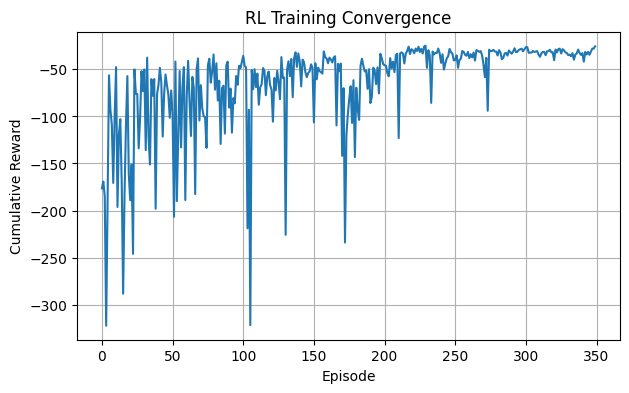

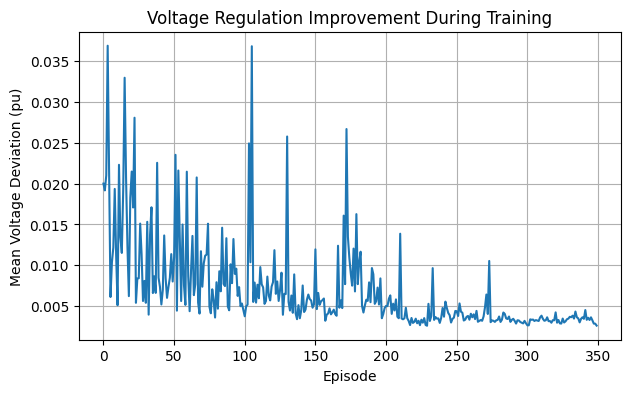

In [4]:
# ===== RL Training Curves =====
plt.figure(figsize=(7,4))
plt.plot(rl_logs["episode_reward"])
plt.xlabel("Episode")
plt.ylabel("Cumulative Reward")
plt.title("RL Training Convergence")
plt.grid(True)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(rl_logs["episode_voltage_deviation"])
plt.xlabel("Episode")
plt.ylabel("Mean Voltage Deviation (pu)")
plt.title("Voltage Regulation Improvement During Training")
plt.grid(True)
plt.show()


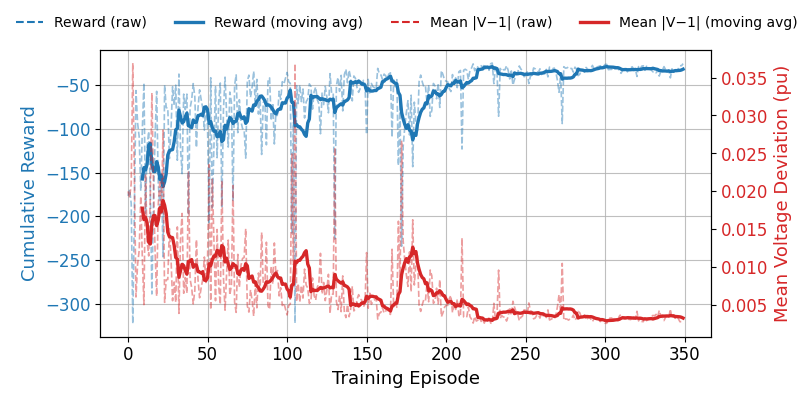

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def moving_average(x, w=10):
    return np.convolve(x, np.ones(w) / w, mode="valid")

episodes = np.arange(len(rl_logs["episode_reward"]))

fig, ax1 = plt.subplots(figsize=(8, 4))

# ---------------- Font sizes ----------------
LABEL_FONTSIZE = 13
TICK_FONTSIZE  = 12

# ---- Left axis: Reward ----
ax1.plot(
    episodes,
    rl_logs["episode_reward"],
    color="tab:blue",
    alpha=0.45,
    linestyle="--",
    linewidth=1.2
)
ax1.plot(
    episodes[9:],
    moving_average(rl_logs["episode_reward"], 10),
    color="tab:blue",
    linewidth=2.4
)
ax1.set_xlabel("Training Episode", fontsize=LABEL_FONTSIZE)
ax1.set_ylabel("Cumulative Reward", color="tab:blue", fontsize=LABEL_FONTSIZE)
ax1.tick_params(axis="x", labelsize=TICK_FONTSIZE)
ax1.tick_params(axis="y", labelsize=TICK_FONTSIZE, labelcolor="tab:blue")

# ---- Right axis: Voltage deviation ----
ax2 = ax1.twinx()
ax2.plot(
    episodes,
    rl_logs["episode_voltage_deviation"],
    color="tab:red",
    alpha=0.45,
    linestyle="--",
    linewidth=1.2
)
ax2.plot(
    episodes[9:],
    moving_average(rl_logs["episode_voltage_deviation"], 10),
    color="tab:red",
    linewidth=2.4
)
ax2.set_ylabel("Mean Voltage Deviation (pu)", color="tab:red", fontsize=LABEL_FONTSIZE)
ax2.tick_params(axis="y", labelsize=TICK_FONTSIZE, labelcolor="tab:red")

# ---- Custom Legend (clear + meaningful) ----
legend_lines = [
    Line2D([0], [0], color="tab:blue", linestyle="--", linewidth=1.5,
           label="Reward (raw)"),
    Line2D([0], [0], color="tab:blue", linestyle="-", linewidth=2.4,
           label="Reward (moving avg)"),
    Line2D([0], [0], color="tab:red", linestyle="--", linewidth=1.5,
           label="Mean |V−1| (raw)"),
    Line2D([0], [0], color="tab:red", linestyle="-", linewidth=2.4,
           label="Mean |V−1| (moving avg)")
]

fig.legend(
    handles=legend_lines,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 1)
)

# ---- Styling ----
ax1.grid(True, alpha=0.8)
plt.tight_layout(rect=[0, 0, 1, 0.92])

# ---- Save as PDF ----
plt.savefig("RL_Training_Convergence.pdf", format="pdf", bbox_inches="tight")
plt.show()


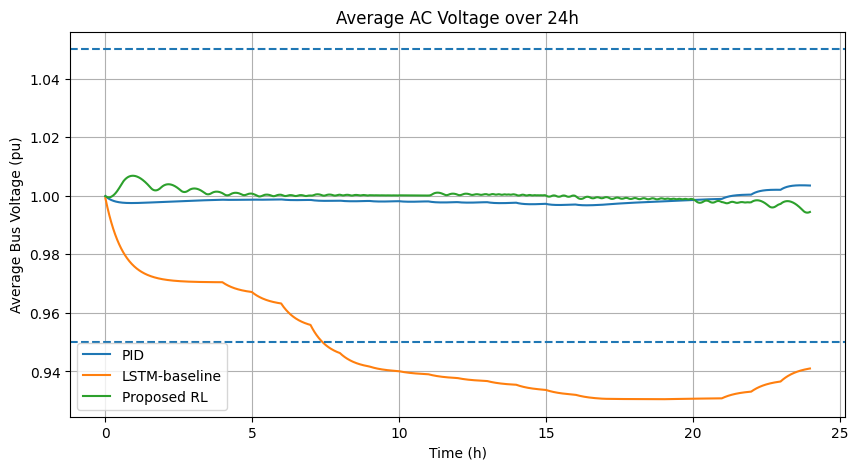

In [6]:
# Plot average voltage
plt.figure(figsize=(10,5))
plt.plot(sim_pid["t"], np.mean(sim_pid["V"], axis=1), label="PID")
plt.plot(sim_lstm["t"], np.mean(sim_lstm["V"], axis=1), label="LSTM-baseline")
plt.plot(sim_rl["t"], np.mean(sim_rl["V"], axis=1), label="Proposed RL")
plt.axhline(1.05, linestyle="--")
plt.axhline(0.95, linestyle="--")
plt.xlabel("Time (h)")
plt.ylabel("Average Bus Voltage (pu)")
plt.title("Average AC Voltage over 24h")
plt.legend()
plt.grid(True)
plt.show()


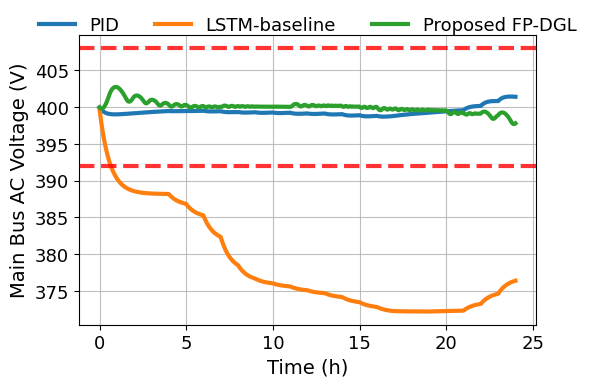

In [6]:
# ===== Average AC Voltage in Volts =====

V_nom_ll = 400.0  # nominal line-to-line voltage (V)

plt.figure(figsize=(6, 4))

# ---------------- Font sizes ----------------
LABEL_FONTSIZE = 14
TICK_FONTSIZE  = 13
LEGEND_FONTSIZE = 13

# ---------------- Plots ----------------
plt.plot(
    sim_pid["t"],
    np.mean(sim_pid["V"], axis=1) * V_nom_ll,
    label="PID",
    linewidth=3
)

plt.plot(
    sim_lstm["t"],
    np.mean(sim_lstm["V"], axis=1) * V_nom_ll,
    label="LSTM-baseline",
    linewidth=3
)

plt.plot(
    sim_rl["t"],
    np.mean(sim_rl["V"], axis=1) * V_nom_ll,
    label="Proposed FP-DGL",
    linewidth=3,
    linestyle="-"      # 
)

# ---------------- Voltage limits ----------------
plt.axhline(1.02 * V_nom_ll, linestyle="--", color="red", linewidth=3, alpha=0.8)
plt.axhline(0.98 * V_nom_ll, linestyle="--", color="red", linewidth=3, alpha=0.8)

# ---------------- Labels & ticks ----------------
plt.xlabel("Time (h)", fontsize=LABEL_FONTSIZE)
plt.ylabel("Main Bus AC Voltage (V)", fontsize=LABEL_FONTSIZE)
plt.xticks(fontsize=TICK_FONTSIZE)
plt.yticks(fontsize=TICK_FONTSIZE)

# ---------------- Horizontal legend ----------------
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12),
    ncol=3,
    frameon=False,
    fontsize=LEGEND_FONTSIZE
)

plt.grid(True, alpha=0.8)
plt.tight_layout()

# ---- Save as PDF ----
plt.savefig(
    "Average_Main_Bus_AC_Voltage_24h_Islanded.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()



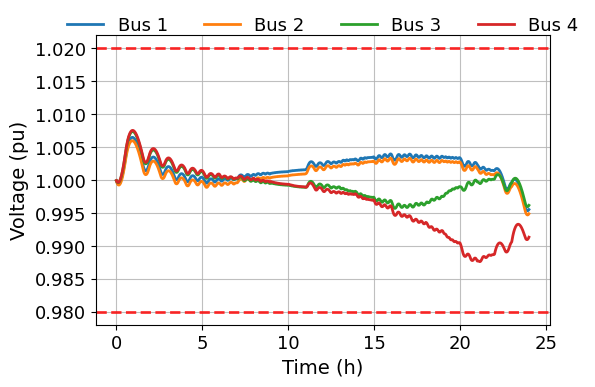

In [27]:
# ===== Proposed RL: Per-Bus Voltages =====

plt.figure(figsize=(6, 4))

# ---------------- Font sizes ----------------
LABEL_FONTSIZE  = 14
TICK_FONTSIZE   = 13
LEGEND_FONTSIZE = 13

# ---------------- Plot per-bus voltages ----------------
for i in range(4):
    linestyle = "-" if i in [2, 3] else "-"   # Bus-3 & Bus-4 dashed
    plt.plot(
        sim_rl["t"],
        sim_rl["V"][:, i],
        label=f"Bus {i+1}",
        linewidth=2,
        linestyle=linestyle
    )

# ---------------- Voltage limits ----------------
plt.axhline(1.02, linestyle="--", linewidth=2, color="red", alpha=0.8)
plt.axhline(0.98, linestyle="--", linewidth=2, color="red", alpha=0.8)

# ---------------- Labels & ticks ----------------
plt.xlabel("Time (h)", fontsize=LABEL_FONTSIZE)
plt.ylabel("Voltage (pu)", fontsize=LABEL_FONTSIZE)
plt.xticks(fontsize=TICK_FONTSIZE)
plt.yticks(fontsize=TICK_FONTSIZE)

# ---------------- Horizontal legend ----------------
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12),
    ncol=4,
    frameon=False,
    fontsize=LEGEND_FONTSIZE
)

#plt.title("Proposed RL: Per-Bus Voltages", fontsize=15)

plt.grid(True, alpha=0.8)
plt.tight_layout()

# ---------------- Save as PDF ----------------
plt.savefig(
    "Proposed_RL_Per_Bus_Voltages.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()


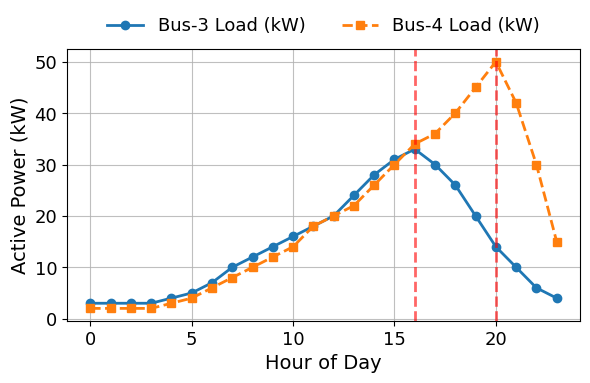

In [ ]:
# ===== 24h Load Profiles (Bus-3 & Bus-4) =====
hours = np.arange(24)

plt.figure(figsize=(6, 4))

# ---------------- Font sizes ----------------
LABEL_FONTSIZE  = 14
TICK_FONTSIZE   = 13
LEGEND_FONTSIZE = 13

# ---------------- Load profiles ----------------
plt.plot(
    hours,
    P3_KW_24,
    marker='o',
    linewidth=2,
    label="Bus-3 Load (kW)"
)

plt.plot(
    hours,
    P4_KW_24,
    marker='s',
    linewidth=2,
    linestyle="--",          # 
    label="Bus-4 Load (kW)"
)

# ---------------- Peak-hour markers ----------------
plt.axvline(16, linestyle="--", color="red", linewidth=2, alpha=0.6)
plt.axvline(20, linestyle="--", color="red", linewidth=2, alpha=0.6)

# ---------------- Labels & ticks ----------------
plt.xlabel("Hour of Day", fontsize=LABEL_FONTSIZE)
plt.ylabel("Active Power (kW)", fontsize=LABEL_FONTSIZE)
plt.xticks(fontsize=TICK_FONTSIZE)
plt.yticks(fontsize=TICK_FONTSIZE)

# ---------------- Horizontal legend ----------------
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.18),
    ncol=2,
    frameon=False,
    fontsize=LEGEND_FONTSIZE
)

plt.grid(True, alpha=0.8)
plt.tight_layout()

# ---------------- Save as PDF ----------------
plt.savefig(
    "Load_Profiles_Bus3_Bus4_24h.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()


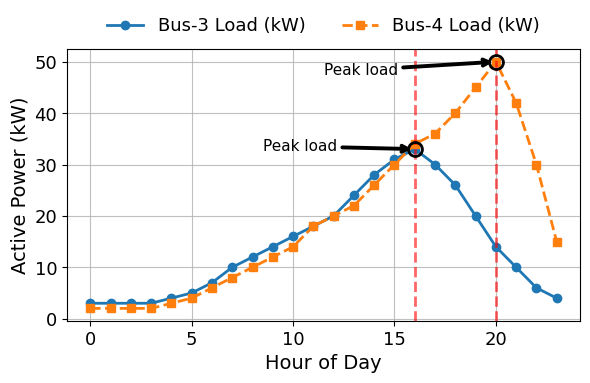

In [47]:
# ===== 24h Load Profiles (Bus-3 & Bus-4) =====
hours = np.arange(24)

plt.figure(figsize=(6, 4))

# ---------------- Font sizes ----------------
LABEL_FONTSIZE  = 14
TICK_FONTSIZE   = 13
LEGEND_FONTSIZE = 13

# ---------------- Load profiles ----------------
plt.plot(
    hours,
    P3_KW_24,
    marker='o',
    linewidth=2,
    label="Bus-3 Load (kW)"
)

plt.plot(
    hours,
    P4_KW_24,
    marker='s',
    linewidth=2,
    linestyle="--",
    label="Bus-4 Load (kW)"
)

# ---------------- Peak-hour markers ----------------
plt.axvline(16, linestyle="--", color="red", linewidth=2, alpha=0.6)
plt.axvline(20, linestyle="--", color="red", linewidth=2, alpha=0.6)

# ---------------- Highlight max points ----------------
# Bus-3 peak at 16 h
plt.plot(
    16,
    P3_KW_24[16],
    marker='o',
    markersize=10,
    markerfacecolor='none',
    markeredgewidth=2,
    markeredgecolor='black'
)

plt.annotate(
    "Peak load",
    xy=(16, P3_KW_24[16]),
    xytext=(8.5, P3_KW_24[15] + 0.05 * max(P3_KW_24)),
    arrowprops=dict(arrowstyle="->", lw=2.8),
    fontsize=11
)

# Bus-4 peak at 20 h
plt.plot(
    20,
    P4_KW_24[20],
    marker='o',
    markersize=10,
    markerfacecolor='none',
    markeredgewidth=2,
    markeredgecolor='black'
)

plt.annotate(
    "Peak load",
    xy=(20, P4_KW_24[20]),
    xytext=(11.5, P4_KW_24[19] + 0.05 * max(P4_KW_24)),
    arrowprops=dict(arrowstyle="->", lw=2.8),
    fontsize=11
)

# ---------------- Labels & ticks ----------------
plt.xlabel("Hour of Day", fontsize=LABEL_FONTSIZE)
plt.ylabel("Active Power (kW)", fontsize=LABEL_FONTSIZE)
plt.xticks(fontsize=TICK_FONTSIZE)
plt.yticks(fontsize=TICK_FONTSIZE)

# ---------------- Horizontal legend ----------------
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.18),
    ncol=2,
    frameon=False,
    fontsize=LEGEND_FONTSIZE
)

plt.grid(True, alpha=0.8)
plt.tight_layout()

# ---------------- Save as PDF ----------------
plt.savefig(
    "Load_Profiles_Bus3_Bus4_24h_with_Peaks.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()


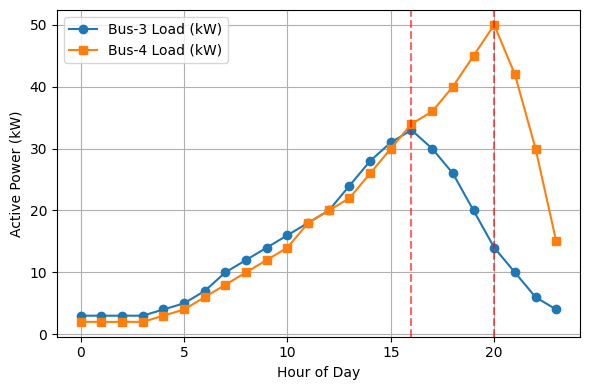

In [30]:
# ===== 24h Load Profiles (Bus-3 & Bus-4) =====
hours = np.arange(24)

plt.figure(figsize=(6,4))
plt.plot(hours, P3_KW_24, marker='o', label="Bus-3 Load (kW)")
plt.plot(hours, P4_KW_24, marker='s', label="Bus-4 Load (kW)")
plt.axvline(16, linestyle="--", color="red", alpha=0.6)
plt.axvline(20, linestyle="--", color="red", alpha=0.6)
plt.xlabel("Hour of Day")
plt.ylabel("Active Power (kW)")
#plt.title("Dynamic Load Profiles of Bus-3 and Bus-4 (24h)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


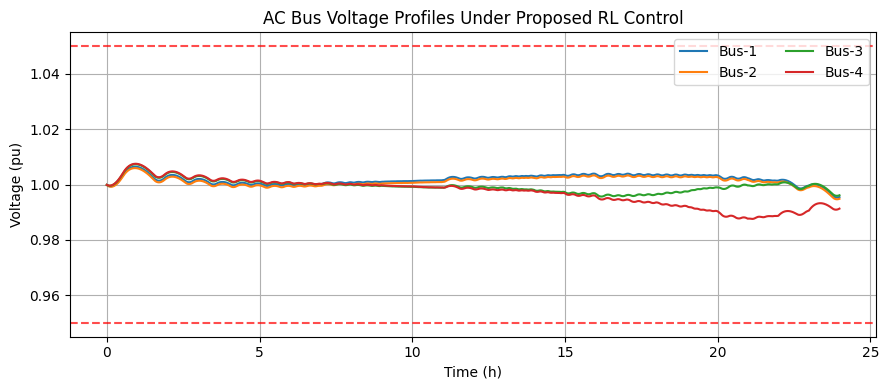

In [34]:
# ===== AC Bus Voltages (Proposed RL) =====
plt.figure(figsize=(9,4))

for i in range(4):
    plt.plot(sim_rl["t"], sim_rl["V"][:, i],
             label=f"Bus-{i+1}")

plt.axhline(1.05, linestyle="--", color="red", alpha=0.7)
plt.axhline(0.95, linestyle="--", color="red", alpha=0.7)

plt.xlabel("Time (h)")
plt.ylabel("Voltage (pu)")
plt.title("AC Bus Voltage Profiles Under Proposed RL Control")
plt.legend(ncol=2)
plt.grid(True)
plt.tight_layout()
plt.show()


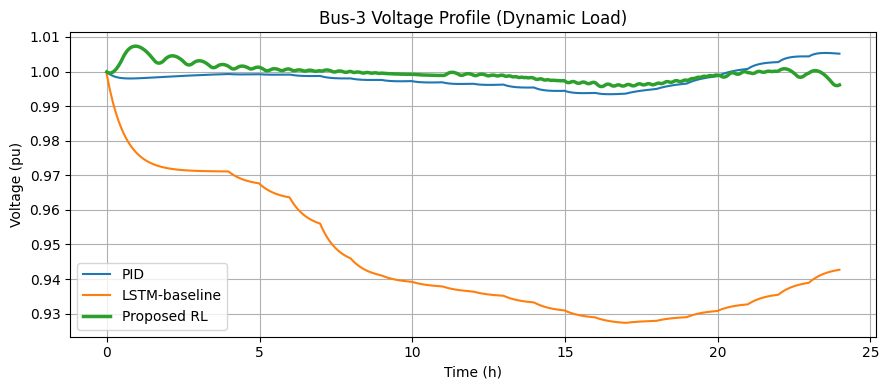

In [35]:
# ===== Bus-3 Voltage Comparison =====
plt.figure(figsize=(9,4))

plt.plot(sim_pid["t"], sim_pid["V"][:, 2], label="PID")
plt.plot(sim_lstm["t"], sim_lstm["V"][:, 2], label="LSTM-baseline")
plt.plot(sim_rl["t"], sim_rl["V"][:, 2], label="Proposed RL", linewidth=2.5)

#plt.axhline(1.05, linestyle="--", color="red", alpha=0.7)
#plt.axhline(0.95, linestyle="--", color="red", alpha=0.7)

plt.xlabel("Time (h)")
plt.ylabel("Voltage (pu)")
plt.title("Bus-3 Voltage Profile (Dynamic Load)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


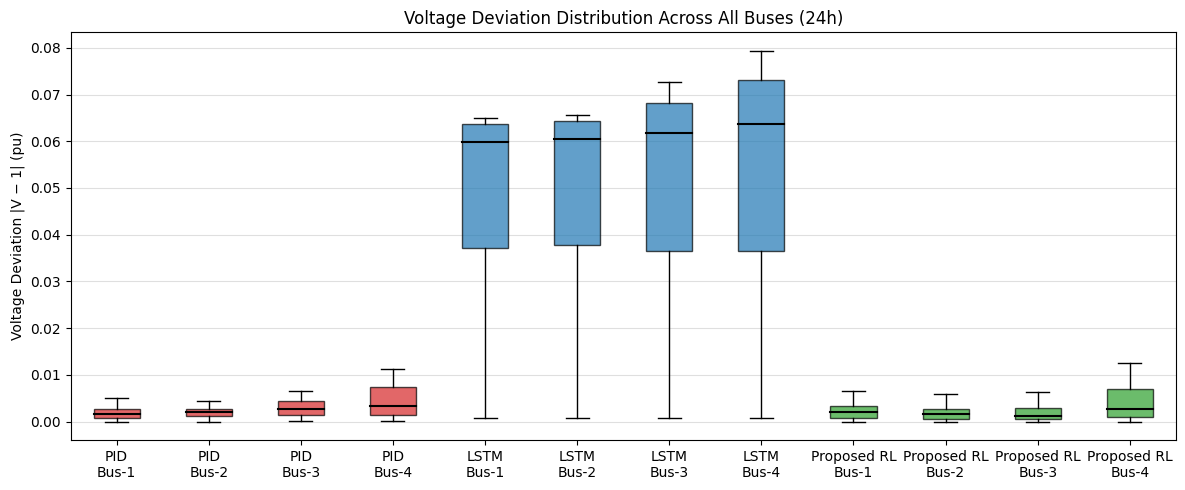

In [36]:
# ===== Boxplot: Voltage Deviation (All Buses × Controllers) =====

# Voltage deviation per bus
def vdev(sim, bus_idx):
    return np.abs(sim["V"][:, bus_idx] - 1.0)

data = []
labels = []

controllers = [
    ("PID", sim_pid),
    ("LSTM", sim_lstm),
    ("Proposed RL", sim_rl),
]

for name, sim in controllers:
    for b in range(4):
        data.append(vdev(sim, b))
        labels.append(f"{name}\nBus-{b+1}")

plt.figure(figsize=(12,5))

bp = plt.boxplot(
    data,
    labels=labels,
    showfliers=False,
    patch_artist=True
)

# Coloring by controller (optional but very nice)
colors = ["#d62728", "#1f77b4", "#2ca02c"]  # PID, LSTM, RL
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(colors[i // 4])
    patch.set_alpha(0.7)

# Make medians black
for median in bp["medians"]:
    median.set_color("black")
    median.set_linewidth(1.5)

plt.ylabel("Voltage Deviation |V − 1| (pu)")
plt.title("Voltage Deviation Distribution Across All Buses (24h)")
plt.grid(True, axis="y", alpha=0.4)
plt.tight_layout()
plt.show()


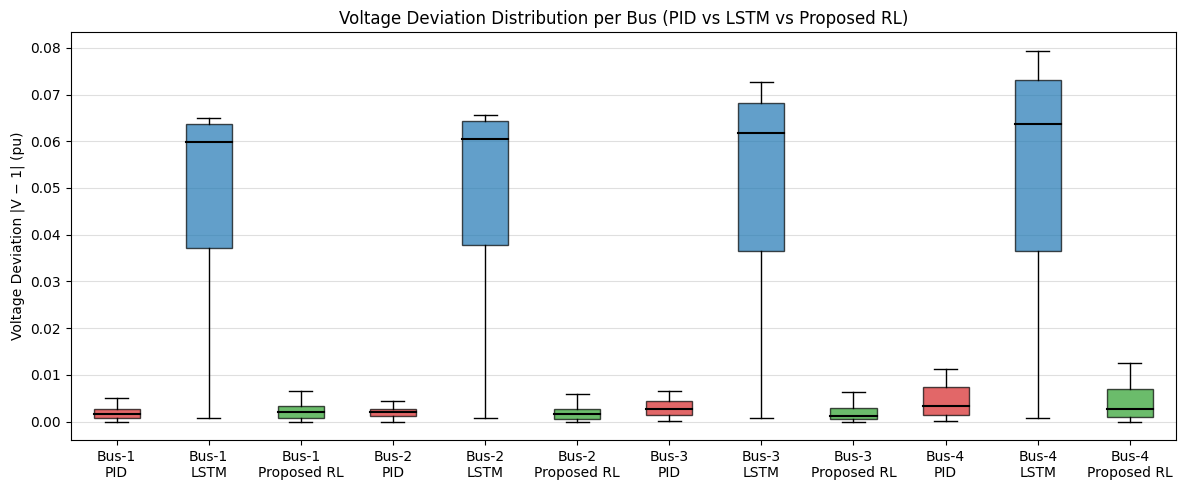

In [37]:
# ===== Boxplot: Voltage Deviation (Per Bus × Controllers) =====

import numpy as np
import matplotlib.pyplot as plt

def vdev(sim, bus_idx):
    return np.abs(sim["V"][:, bus_idx] - 1.0)

controllers = [
    ("PID", sim_pid),
    ("LSTM", sim_lstm),
    ("Proposed RL", sim_rl),
]

data = []
labels = []

# ---- BUS-WISE ORDER ----
for b in range(4):  # Bus-1 .. Bus-4
    for name, sim in controllers:
        data.append(vdev(sim, b))
        labels.append(f"Bus-{b+1}\n{name}")

plt.figure(figsize=(12,5))

bp = plt.boxplot(
    data,
    labels=labels,
    showfliers=False,
    patch_artist=True
)

# Colors per controller
colors = {
    "PID": "#d62728",        # red
    "LSTM": "#1f77b4",       # blue
    "Proposed RL": "#2ca02c" # green
}

# Apply colors (every 3 boxes = one bus)
for i, patch in enumerate(bp["boxes"]):
    ctrl_name = labels[i].split("\n")[1]
    patch.set_facecolor(colors[ctrl_name])
    patch.set_alpha(0.7)

# Make medians black
for median in bp["medians"]:
    median.set_color("black")
    median.set_linewidth(1.5)

plt.ylabel("Voltage Deviation |V − 1| (pu)")
plt.title("Voltage Deviation Distribution per Bus (PID vs LSTM vs Proposed RL)")
plt.grid(True, axis="y", alpha=0.4)
plt.tight_layout()
plt.show()


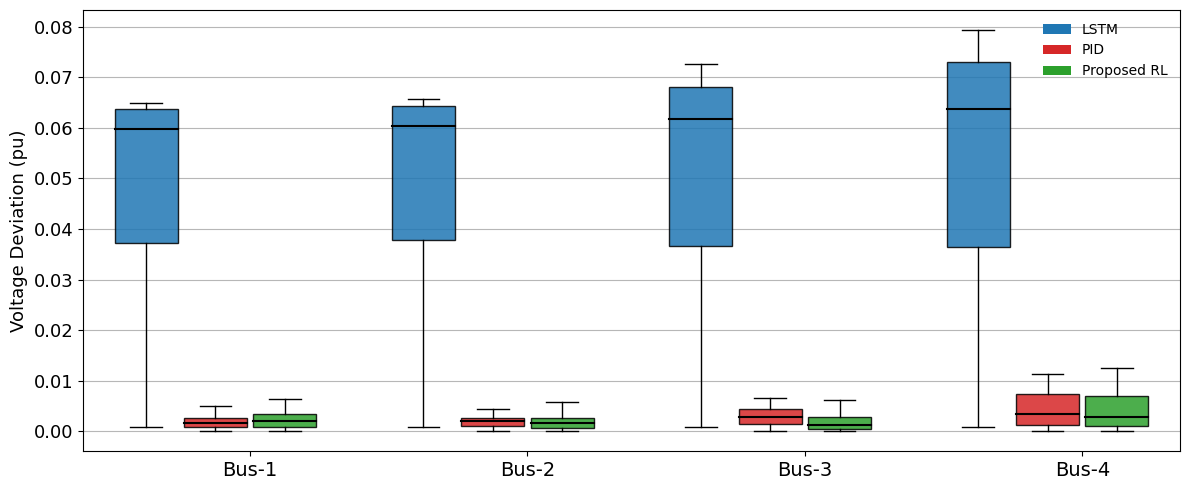

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def vdev(sim, bus_idx):
    return np.abs(sim["V"][:, bus_idx] - 1.0)

# ---- Controllers (ORDER MATTERS) ----
controllers = [
    ("LSTM", sim_lstm),
    ("PID", sim_pid),
    ("Proposed RL", sim_rl),
]

# ---- Colors ----
colors = {
    "PID": "#d62728",         # red
    "LSTM": "#1f77b4",        # blue
    "Proposed RL": "#2ca02c"  # green
}

data = []
positions = []
bus_labels = []

pos = 1.0
step = 0.55   # <-- tighter spacing between controllers
gap  = 0.55   # <-- small gap between buses

# ---- BUS-WISE GROUPING ----
for b in range(4):  # Bus-1 .. Bus-4
    for name, sim in controllers:
        data.append(vdev(sim, b))
        positions.append(pos)
        pos += step
    bus_labels.append(pos - step * 1.5)  # center of bus group
    pos += gap

plt.figure(figsize=(12, 5))

bp = plt.boxplot(
    data,
    positions=positions,
    widths=0.5,      # <-- slightly wider boxes
    showfliers=False,
    patch_artist=True
)

# ---- Apply colors ----
for i, patch in enumerate(bp["boxes"]):
    ctrl_name = controllers[i % 3][0]
    patch.set_facecolor(colors[ctrl_name])
    patch.set_alpha(0.85)

# ---- Median styling ----
for median in bp["medians"]:
    median.set_color("black")
    median.set_linewidth(1.5)

# ---- X-axis: Bus labels only ----
plt.xticks(bus_labels, [f"Bus-{i+1}" for i in range(4)], fontsize=14)

# ---- Y-axis ----
plt.ylabel("Voltage Deviation (pu)", fontsize=13)
plt.yticks(fontsize=13) 

# ---- Legend (ORDERED) ----
legend_handles = [
    Patch(facecolor=colors["LSTM"], label="LSTM"),
    Patch(facecolor=colors["PID"], label="PID"),
    Patch(facecolor=colors["Proposed RL"], label="Proposed RL")
]

plt.legend(
    handles=legend_handles,
    loc="upper right",
    frameon=False
)

# ---- Grid & layout ----
plt.grid(True, axis="y", alpha=0.9)
plt.tight_layout()
plt.show()


C:\Users\asus\AppData\Local\Temp\ipykernel_19252\3247434322.py:206: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


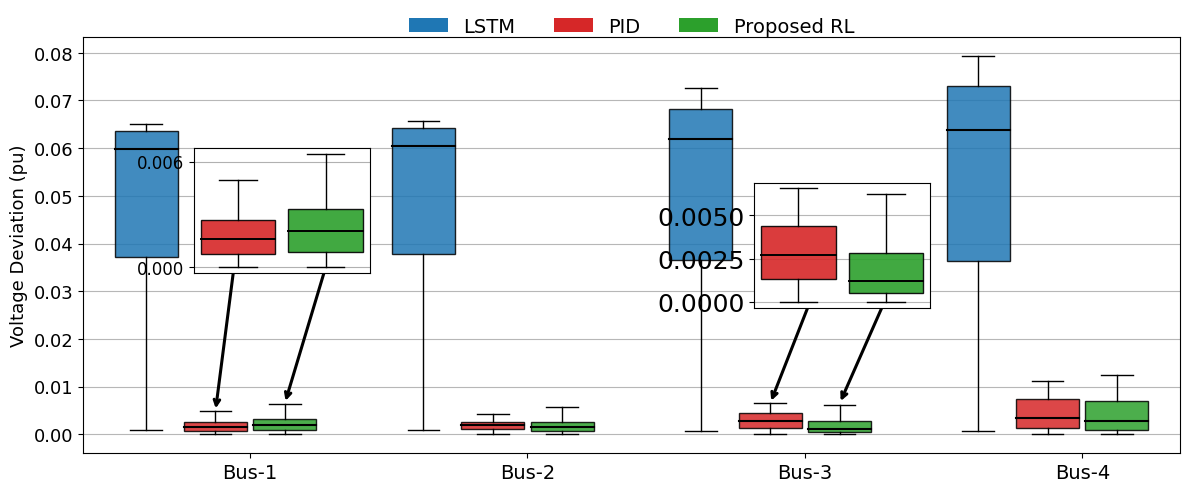

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import MaxNLocator

def vdev(sim, bus_idx):
    return np.abs(sim["V"][:, bus_idx] - 1.0)

# ---- Controllers (ORDER MATTERS) ----
controllers = [
    ("LSTM", sim_lstm),
    ("PID", sim_pid),
    ("Proposed RL", sim_rl),
]

# ---- Colors ----
colors = {
    "PID": "#d62728",
    "LSTM": "#1f77b4",
    "Proposed RL": "#2ca02c"
}

data = []
positions = []
bus_labels = []

pos = 1.0
step = 0.55
gap  = 0.55

# ---- BUS-WISE GROUPING ----
for b in range(4):
    for name, sim in controllers:
        data.append(vdev(sim, b))
        positions.append(pos)
        pos += step
    bus_labels.append(pos - step * 1.5)
    pos += gap

fig, ax = plt.subplots(figsize=(12, 5))

bp = ax.boxplot(
    data,
    positions=positions,
    widths=0.5,
    showfliers=False,
    patch_artist=True
)

# ---- Apply colors ----
for i, patch in enumerate(bp["boxes"]):
    ctrl_name = controllers[i % 3][0]
    patch.set_facecolor(colors[ctrl_name])
    patch.set_alpha(0.85)

# ---- Median styling ----
for median in bp["medians"]:
    median.set_color("black")
    median.set_linewidth(1.5)

# ---- Axes ----
ax.set_xticks(bus_labels)
ax.set_xticklabels([f"Bus-{i+1}" for i in range(4)], fontsize=14)
ax.set_ylabel("Voltage Deviation (pu)", fontsize=13)
ax.tick_params(axis="y", labelsize=13)

# ---- Legend ----
legend_handles = [
    Patch(facecolor=colors["LSTM"], label="LSTM"),
    Patch(facecolor=colors["PID"], label="PID"),
    Patch(facecolor=colors["Proposed RL"], label="Proposed RL")
]

ax.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.09),  # centered above plot
    ncol=3,                      # 👈 horizontal layout
    frameon=False,
    fontsize=14
)



ax.grid(True, axis="y", alpha=0.9)

# =========================================================
# 🔍 SMALL INSET: Bus-1 (PID vs Proposed RL)
# =========================================================
axins = inset_axes(
    ax,
    width="16%",     # smaller inset
    height="30%",
    loc="upper left",
    borderpad=8.0
)

# Bus-1 data
bus1_pid = vdev(sim_pid, 0)
bus1_rl  = vdev(sim_rl, 0)

bp_in = axins.boxplot(
    [bus1_pid, bus1_rl],
    widths=0.85,
    showfliers=False,
    patch_artist=True
)

bp_in["boxes"][0].set_facecolor(colors["PID"])
bp_in["boxes"][1].set_facecolor(colors["Proposed RL"])
for box in bp_in["boxes"]:
    box.set_alpha(0.9)

for median in bp_in["medians"]:
    median.set_color("black")
    median.set_linewidth(1.4)

# ---- Clean inset (Y-axis numbers ON, grid ON) ----
axins.set_xticks([])                           # hide x ticks
axins.yaxis.set_major_locator(MaxNLocator(nbins=1))  # ✅ only 2–3 Y values
axins.tick_params(axis="y", labelsize=12) # hide y numbers only
axins.grid(True, axis="y", alpha=0.99)         # grid works now

# =========================================================
# 🔍 SECOND INSET: Bus-3 (PID vs Proposed RL)
# =========================================================
axins2 = inset_axes(
    ax,
    width="16%",
    height="30%",
    loc="center right",
    borderpad=18      # slightly shifted so it doesn't overlap Bus-1 inset
)

# Bus-3 data (index = 2)
bus3_pid = vdev(sim_pid, 2)
bus3_rl  = vdev(sim_rl, 2)

bp_in2 = axins2.boxplot(
    [bus3_pid, bus3_rl],
    widths=0.85,
    showfliers=False,
    patch_artist=True
)

bp_in2["boxes"][0].set_facecolor(colors["PID"])
bp_in2["boxes"][1].set_facecolor(colors["Proposed RL"])
for box in bp_in2["boxes"]:
    box.set_alpha(0.9)

for median in bp_in2["medians"]:
    median.set_color("black")
    median.set_linewidth(1.4)

# ---- Clean inset (few Y-ticks + grid) ----
axins2.set_xticks([])
axins2.yaxis.set_major_locator(MaxNLocator(nbins=3))
axins2.tick_params(axis="y", labelsize=18)
axins2.grid(True, axis="y", alpha=0.9)


# =========================================================
# ➤ ARROWS pointing to PID & RL (Bus-1)
# =========================================================
pid_pos = positions[1]   # Bus-1 PID
rl_pos  = positions[2]   # Bus-1 Proposed RL

ax.annotate(
    "",
    xy=(pid_pos, np.percentile(bus1_pid, 98)),
    xytext=(0.15, 0.70),
    textcoords="axes fraction",
    arrowprops=dict(arrowstyle="->", lw=2.2)
)

ax.annotate(
    "",
    xy=(rl_pos, np.percentile(bus1_rl, 100)),
    xytext=(0.25, 0.70),
    textcoords="axes fraction",
    arrowprops=dict(arrowstyle="->", lw=2.2)
)

# ---- Arrows pointing to Bus-3 PID & RL ----
pid_pos_b3 = positions[7]   # Bus-3 PID
rl_pos_b3  = positions[8]   # Bus-3 Proposed RL

ax.annotate(
    "",
    xy=(pid_pos_b3, np.percentile(bus3_pid, 98)),
    xytext=(0.68, 0.48),
    textcoords="axes fraction",
    arrowprops=dict(arrowstyle="->", lw=2.2)
)

ax.annotate(
    "",
    xy=(rl_pos_b3, np.percentile(bus3_rl, 98)),
    xytext=(0.75, 0.48),
    textcoords="axes fraction",
    arrowprops=dict(arrowstyle="->", lw=2.2)
)


plt.tight_layout()

# ---- Save as PDF ----
plt.savefig(
    "Voltage_Deviation_Boxplot_with_Inset.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()